In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn
from collections import Counter
import os

In [33]:
path_to_folder = 'D:\\base'
path_to_file_1 = path_to_folder + '\\disp_1.csv'
path_to_file_2 = path_to_folder + '\\disp_2.csv'

df_1 = pd.read_csv(path_to_file_1, 
                 sep='\s+',           # разделитель: пробелы/табуляции
                 skiprows=1,          # пропускаем первую строку (заголовки не в том формате)
                 header=None,         # нет заголовков в данных
                 names=['el_id', 'el_a', 'el_b', 'Node1_UY', 'Node2_UX', 'Node3_UY'])  # задаем имена колонок

df_2 = pd.read_csv(path_to_file_2, 
                 sep='\s+',           # разделитель: пробелы/табуляции
                 skiprows=1,          # пропускаем первую строку (заголовки не в том формате)
                 header=None,         # нет заголовков в данных
                 names=['el_id1', 'el_a1', 'el_b1', 'el_id2', 'el_a2', 'el_b2', 'Node1_UY', 'Node2_UX', 'Node3_UY'])  # задаем имена колонок

#df_1['el_id'] = np.where((df_1['el_id'] >= 12613) & (df_1['el_id'] <= 12635), 25248 - df_1['el_id'], df_1['el_id'])

df_1['num_zones'] = 0 # 1 параметр
df_2['num_zones'] = 1 # 2 параметра

df_1 = df_1.drop(['el_id', 'el_a', 'el_b'], axis=1)
df_2 = df_2.drop(['el_id1', 'el_a1', 'el_b1', 'el_id2', 'el_a2', 'el_b2'], axis=1)

df = pd.concat([df_1, df_2], ignore_index=True).drop_duplicates()
df

,Node1_UY,Node2_UX,Node3_UY,num_zones
0,-3.236724,-3.186431,-0.148842,0
1,-2.105566,-2.352659,-0.155641,0
2,-1.989172,-2.344222,8.947892,0
3,-1.493940,1.328918,2.753204,0
4,-0.018817,0.040055,0.350640,0
...,...,...,...,...
1995,-25.374454,-117.117736,14.912259,1
1996,-7.941832,-6.308338,9.881089,1
1997,-1.877859,-4.205142,2.015826,1
1998,-7.192652,-2.080246,7.499114,1


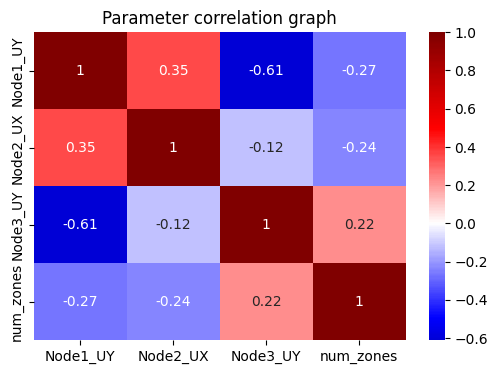

In [34]:
plt.figure(figsize=(6, 4))
seaborn.heatmap(df.corr(), annot=True, cmap='seismic', center=0)
plt.title('Parameter correlation graph')
plt.show()

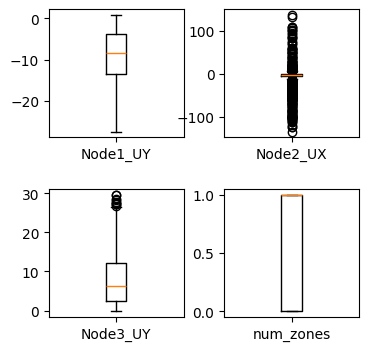

In [35]:
labels = df.columns.to_list()
fig, ax = plt.subplots(2, 2, figsize=(4, 4))
fig.subplots_adjust(hspace=0.4, wspace=0.3) 

for i in range(4):
    ax[i // 2, i % 2].boxplot(df.loc[:,[labels[i]]], tick_labels = [labels[i]])

plt.show()

In [36]:
from sklearn.preprocessing import MinMaxScaler, QuantileTransformer, StandardScaler

X = df[['Node1_UY', 'Node2_UX', 'Node3_UY']].to_numpy()
y = df.drop(['Node1_UY', 'Node2_UX', 'Node3_UY'], axis=1).to_numpy().flatten() #num_zones

scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

# scaler_y = StandardScaler()
# y_scaled = scaler_y.fit_transform(y)

In [115]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X_scaled, 
    y, 
    test_size=0.15, 
    random_state=42,
    stratify=y
)

In [146]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=500, criterion='entropy', max_depth=60, min_samples_split=2
                             , min_samples_leaf=2, random_state=42, verbose=0, bootstrap=False)
clf.fit(x_train, y_train)

print(f'точность на обучающей выборке: {clf.score(x_train, y_train):.3f}, на тествой: {clf.score(x_test, y_test):.3f}')

точность на обучающей выборке: 0.999, на тествой: 0.803


In [157]:
import lightgbm as lgb

base_lgb = lgb.LGBMClassifier(verbose=-1, random_state=42, n_estimators=50, num_leaves = 30
                              , max_depth = 30, learning_rate = 0.1, min_child_samples = 5)

base_lgb.fit(x_train, y_train)

print(f'точность на обучающей выборке: {base_lgb.score(x_train, y_train):.3f}, на тествой: {base_lgb.score(x_test, y_test):.3f}')

точность на обучающей выборке: 0.949, на тествой: 0.807


D:\zmei\envs\tf_gpu_windows\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\zmei\envs\tf_gpu_windows\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [280]:
import tensorflow as tf
import keras
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers

model = keras.Sequential([
    keras.Input(shape=(x_train.shape[1],)),
    keras.layers.Dense(4),
    
    keras.layers.Dense(16, activation='leaky_relu'
                       # , kernel_regularizer=regularizers.l2(1e-5)
                      ),
    keras.layers.BatchNormalization(),
    # keras.layers.Dropout(0.2),

    keras.layers.Dense(64, activation='leaky_relu'
                       , kernel_regularizer=regularizers.l2(1e-5)
                      ),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(256, activation='leaky_relu'
                       , kernel_regularizer=regularizers.l2(1e-5)
                      ),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(512, activation='leaky_relu'
                       , kernel_regularizer=regularizers.l2(1e-5)
                      ),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(1024, activation='leaky_relu'
                       , kernel_regularizer=regularizers.l2(1e-5)
                      ),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(512, activation='leaky_relu'
                       , kernel_regularizer=regularizers.l2(1e-5)
                      ),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(256, activation='leaky_relu'
                       , kernel_regularizer=regularizers.l2(1e-5)
                      ),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(64, activation='leaky_relu'
                       , kernel_regularizer=regularizers.l2(1e-5)
                      ),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(16, activation='leaky_relu'
                       # , kernel_regularizer=regularizers.l2(1e-5)
                      ),
    keras.layers.BatchNormalization(),
    # keras.layers.Dropout(0.2),

    keras.layers.Dense(4),
    keras.layers.Dense(2, activation='softmax')
])

model.compile( optimizer = keras.optimizers.Adam(learning_rate = 1e-3),
                loss= 'sparse_categorical_crossentropy',
                metrics = ['accuracy']
                )

callbacks = [
    EarlyStopping(monitor='val_loss', patience=150, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=75, min_lr=1e-6, verbose=1)
]

In [281]:
history = model.fit(x_train, y_train, validation_split=0.2, batch_size=64, epochs=600
                    ,callbacks=callbacks
                    , verbose=0)


Epoch 223: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 301: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 472: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Restoring model weights from the end of the best epoch: 397.

Epoch 547: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Epoch 547: early stopping


In [282]:
from sklearn.metrics import accuracy_score

y_pred_test = np.argmax(model.predict(x_test), axis = 1)
y_pred_train = np.argmax(model.predict(x_train), axis = 1)

print(f"точность на обучающей выборке: {accuracy_score(y_train, y_pred_train)*100:.1f}%, на тестовой: {accuracy_score(y_test, y_pred_test)*100:.1f}%")

54/54 [==============================] - 0s 2ms/step
точность на обучающей выборке: 87.8%, на тестовой: 88.3%


In [283]:
print('-----log_reg-----')
print(f'точность на обучающей выборке: {clf.score(x_train, y_train)*100:.1f}%, на тестовой: {clf.score(x_test, y_test)*100:.1f}%')
print('-------lgb-------')
print(f'точность на обучающей выборке: {base_lgb.score(x_train, y_train)*100:.1f}%, на тестовой: {base_lgb.score(x_test, y_test)*100:.1f}%')
print('------neural-----')
print(f"точность на обучающей выборке: {accuracy_score(y_train, y_pred_train)*100:.1f}%, на тестовой: {accuracy_score(y_test, y_pred_test)*100:.1f}%")

-----log_reg-----
точность на обучающей выборке: 99.9%, на тестовой: 80.3%
-------lgb-------
точность на обучающей выборке: 94.9%, на тестовой: 80.7%
------neural-----
точность на обучающей выборке: 87.8%, на тестовой: 88.3%


D:\zmei\envs\tf_gpu_windows\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\zmei\envs\tf_gpu_windows\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [284]:
#лучшие результаты для нейронной сети, поэтому берем ее

In [288]:
#model.save('model_num_zones', save_format='tf')

In [289]:
import joblib
joblib.dump(scaler_X, 'scaler_X_num_zones.pkl')

['scaler_X_num_zones.pkl']